# Predictive Analytics for Marketing: Personal Loan Campaign Response
**CIA Project — Marketing Analytics**

**Business problem:** A bank's marketing team wants to run a targeted campaign to convert existing depositor (liability) customers into personal loan customers. Mass campaigns are costly and get very low response rates. This notebook builds a classifier to predict which customers are most likely to accept a personal loan offer, so marketing can target the right people  increasing campaign conversion and cutting cost.

**Dataset:** `Bank_Personal_Loan_Modelling.csv` — 5000 bank customers, 14 attributes.
**Target:** `Personal Loan` (1 = accepted the loan offer in a past campaign, 0 = did not)

**Models compared:** Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN)



## Step 1 — Install/import libraries
Colab already has all of these pre-installed, so this cell just imports them.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("Libraries loaded.")

Libraries loaded.


## Step 2 — Upload the dataset



In [3]:
from google.colab import files
uploaded = files.upload()   # choose Bank_Personal_Loan_Modelling.csv
DATA_PATH = list(uploaded.keys())[0]
print("Loaded file:", DATA_PATH)

Saving Bank_Personal_Loan_Modelling.csv to Bank_Personal_Loan_Modelling.csv
Loaded file: Bank_Personal_Loan_Modelling.csv


## Step 3 — Load and inspect the data

In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [6]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## Step 4 — Data cleaning
- `ID` and `ZIP Code` are identifiers with no predictive value so  dropping  them.
- `Experience` has a handful of negative values (data-entry errors) fixing it  with `abs()`.
- Confirm there are no missing values.

In [7]:
df = df.drop(columns=["ID", "ZIP Code"])
df["Experience"] = df["Experience"].abs()
df = df.rename(columns={"Personal Loan": "PersonalLoan"})

print("Missing values total:", df.isnull().sum().sum())
print("\nTarget class balance:")
print(df["PersonalLoan"].value_counts(normalize=True))

Missing values total: 0

Target class balance:
PersonalLoan
0    0.904
1    0.096
Name: proportion, dtype: float64


## Step 5 — Exploratory Data Analysis (EDA)


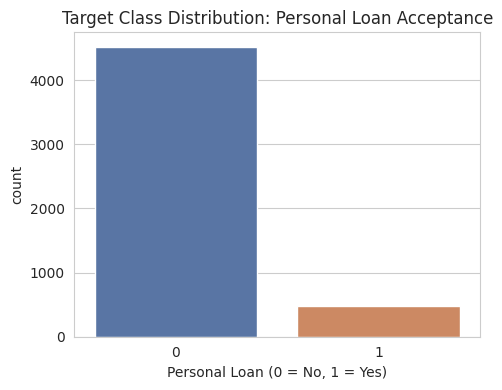

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x="PersonalLoan", data=df, palette=["#4C72B0","#DD8452"])
plt.title("Target Class Distribution: Personal Loan Acceptance")
plt.xlabel("Personal Loan (0 = No, 1 = Yes)")
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150)
plt.show()

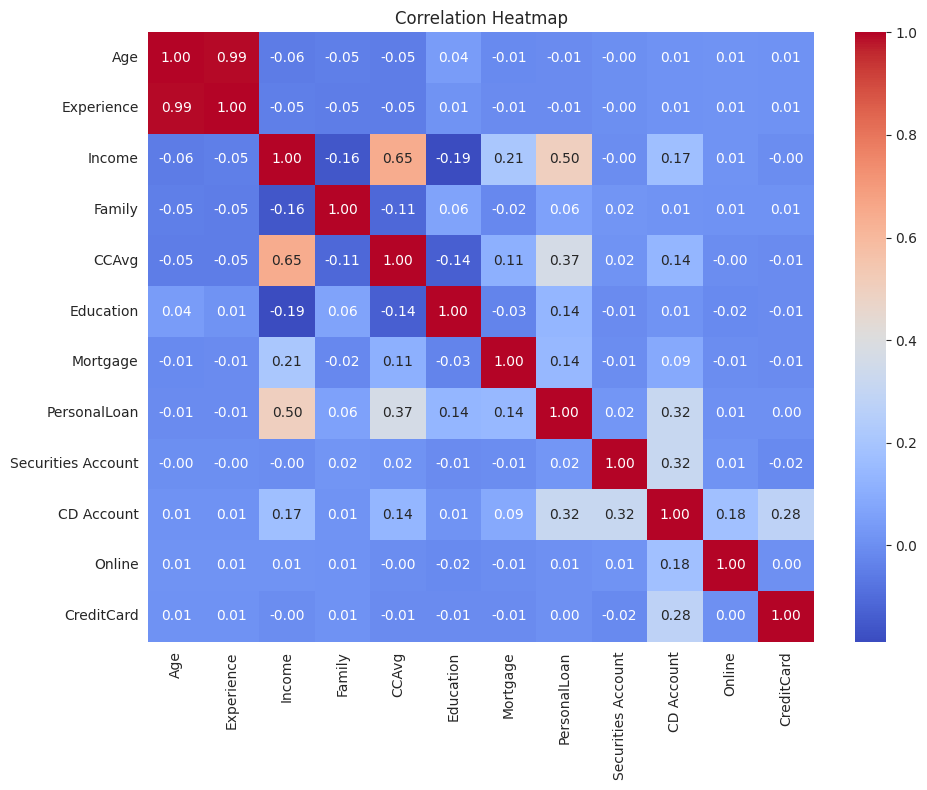

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.png", dpi=150)
plt.show()

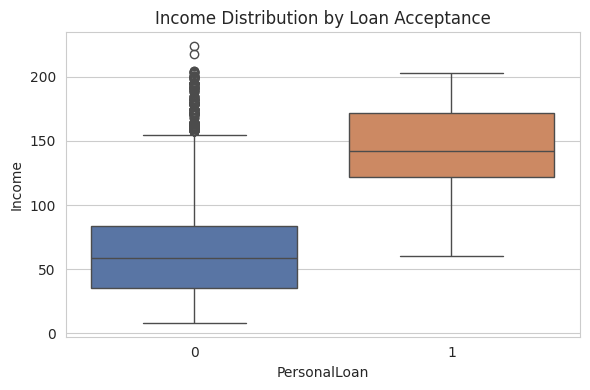

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x="PersonalLoan", y="Income", data=df, palette=["#4C72B0","#DD8452"])
plt.title("Income Distribution by Loan Acceptance")
plt.tight_layout()
plt.savefig("03_income_vs_loan.png", dpi=150)
plt.show()

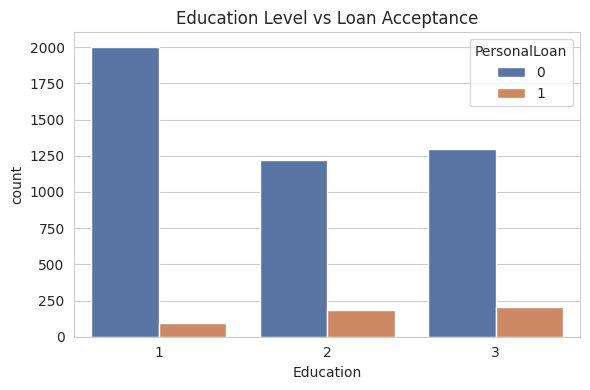

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="Education", hue="PersonalLoan", data=df, palette=["#4C72B0","#DD8452"])
plt.title("Education Level vs Loan Acceptance")
plt.tight_layout()
plt.savefig("04_education_vs_loan.png", dpi=150)
plt.show()

## Step 6 — Train/test split and scaling
- 75% train / 25% test, **stratified** on the target so both sets keep the same ~9.6% loan-acceptance ratio.
- Features are scaled with `StandardScaler` — this matters a lot for Logistic Regression and KNN (distance/gradient based), and is harmless for the tree models.

In [12]:
X = df.drop(columns=["PersonalLoan"])
y = df["PersonalLoan"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (3750, 11)  Test shape: (1250, 11)


## Step 7 — Train the 4 models
Each model is tuned with a small `GridSearchCV` (5-fold cross-validation, optimizing F1-score since the classes are imbalanced ~90/10).

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {}

# 1. Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid={"C": [0.01, 0.1, 1, 10]},
    cv=cv, scoring="f1", n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)
models["Logistic Regression"] = ("scaled", lr_grid.best_estimator_)
print("Logistic Regression best params:", lr_grid.best_params_)

Logistic Regression best params: {'C': 10}


In [14]:
# 2. Decision Tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={"max_depth": [3, 5, 7, 10], "min_samples_leaf": [1, 5, 10]},
    cv=cv, scoring="f1", n_jobs=-1
)
dt_grid.fit(X_train, y_train)
models["Decision Tree"] = ("raw", dt_grid.best_estimator_)
print("Decision Tree best params:", dt_grid.best_params_)

Decision Tree best params: {'max_depth': 5, 'min_samples_leaf': 10}


In [15]:
# 3. Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid={"n_estimators": [100, 200], "max_depth": [5, 10, None]},
    cv=cv, scoring="f1", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
models["Random Forest"] = ("raw", rf_grid.best_estimator_)
print("Random Forest best params:", rf_grid.best_params_)

Random Forest best params: {'max_depth': 10, 'n_estimators': 100}


In [16]:
# 4. KNN
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={"n_neighbors": [3, 5, 7, 9, 11]},
    cv=cv, scoring="f1", n_jobs=-1
)
knn_grid.fit(X_train_scaled, y_train)
models["KNN"] = ("scaled", knn_grid.best_estimator_)
print("KNN best params:", knn_grid.best_params_)

KNN best params: {'n_neighbors': 3}


## Step 8 — Evaluate every model
Metrics used: **Accuracy, Precision, Recall, F1-score, ROC-AUC** — plus a confusion matrix and ROC curve per model. F1/ROC-AUC matter most here because the classes are imbalanced (only ~9.6% of customers accepted the loan), so accuracy alone would be misleading.

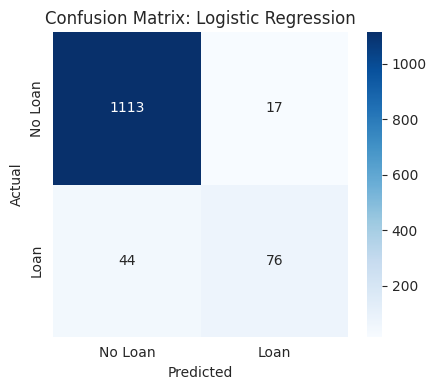


--- Logistic Regression ---
              precision    recall  f1-score   support

     No Loan       0.96      0.98      0.97      1130
        Loan       0.82      0.63      0.71       120

    accuracy                           0.95      1250
   macro avg       0.89      0.81      0.84      1250
weighted avg       0.95      0.95      0.95      1250



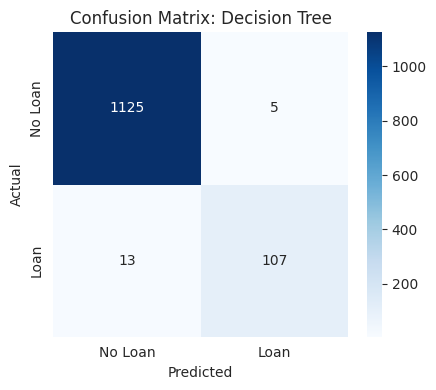


--- Decision Tree ---
              precision    recall  f1-score   support

     No Loan       0.99      1.00      0.99      1130
        Loan       0.96      0.89      0.92       120

    accuracy                           0.99      1250
   macro avg       0.97      0.94      0.96      1250
weighted avg       0.99      0.99      0.99      1250



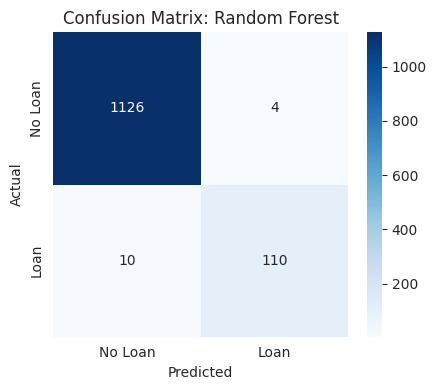


--- Random Forest ---
              precision    recall  f1-score   support

     No Loan       0.99      1.00      0.99      1130
        Loan       0.96      0.92      0.94       120

    accuracy                           0.99      1250
   macro avg       0.98      0.96      0.97      1250
weighted avg       0.99      0.99      0.99      1250



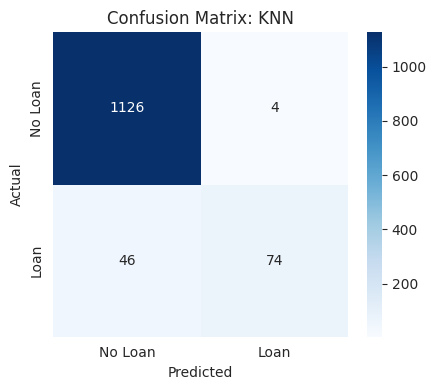


--- KNN ---
              precision    recall  f1-score   support

     No Loan       0.96      1.00      0.98      1130
        Loan       0.95      0.62      0.75       120

    accuracy                           0.96      1250
   macro avg       0.95      0.81      0.86      1250
weighted avg       0.96      0.96      0.96      1250



In [17]:
results = []
roc_data = {}

for name, (kind, model) in models.items():
    X_te = X_test_scaled if kind == "scaled" else X_test
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name, "Accuracy": round(acc,4), "Precision": round(prec,4),
        "Recall": round(rec,4), "F1-Score": round(f1,4), "ROC-AUC": round(auc,4)
    })

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Loan","Loan"], yticklabels=["No Loan","Loan"])
    plt.title(f"Confusion Matrix: {name}")
    plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ','_')}.png", dpi=150)
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["No Loan","Loan"]))

## Step 9 — Model comparison leaderboard
Ranked by F1-score (best metric for this imbalanced marketing-response problem).

In [18]:
leaderboard = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1
leaderboard.index.name = "Rank"
leaderboard.to_csv("leaderboard.csv")
leaderboard

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Rank,,,,,,
1,Random Forest,0.9888,0.9649,0.9167,0.9402,0.9988
2,Decision Tree,0.9856,0.9554,0.8917,0.9224,0.9973
3,KNN,0.9600,0.9487,0.6167,0.7475,0.9233
4,Logistic Regression,0.9512,0.8172,0.6333,0.7136,0.9625


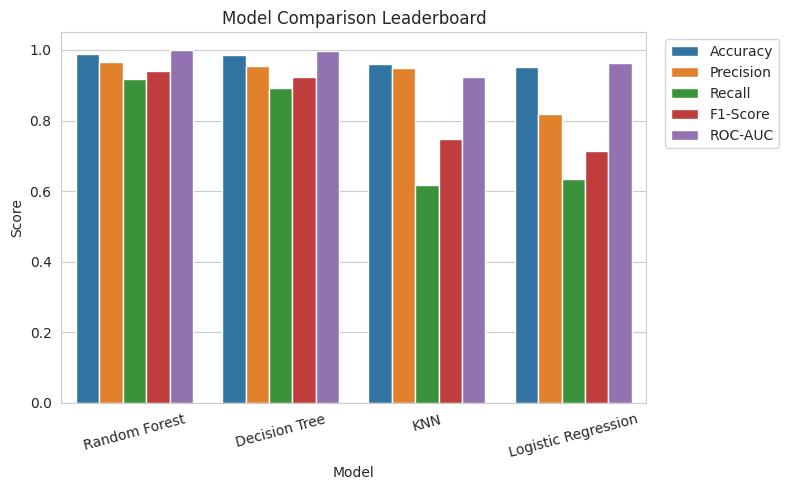

In [19]:
plt.figure(figsize=(8,5))
lb_melt = leaderboard.melt(id_vars="Model",
    value_vars=["Accuracy","Precision","Recall","F1-Score","ROC-AUC"],
    var_name="Metric", value_name="Score")
sns.barplot(data=lb_melt, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison Leaderboard")
plt.ylim(0,1.05)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig("05_leaderboard_chart.png", dpi=150)
plt.show()

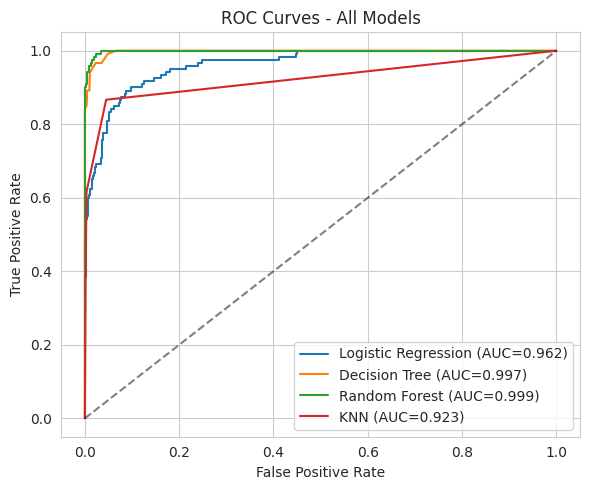

Best performing model based on F1-Score: Random Forest


In [20]:
plt.figure(figsize=(6,5))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend()
plt.tight_layout()
plt.savefig("06_roc_curves.png", dpi=150)
plt.show()

best_model_name = leaderboard.iloc[0]["Model"]
print(f"Best performing model based on F1-Score: {best_model_name}")

## Step 10 — Feature importance (business insight)
Uses the Random Forest to show which customer attributes drive loan acceptance the most

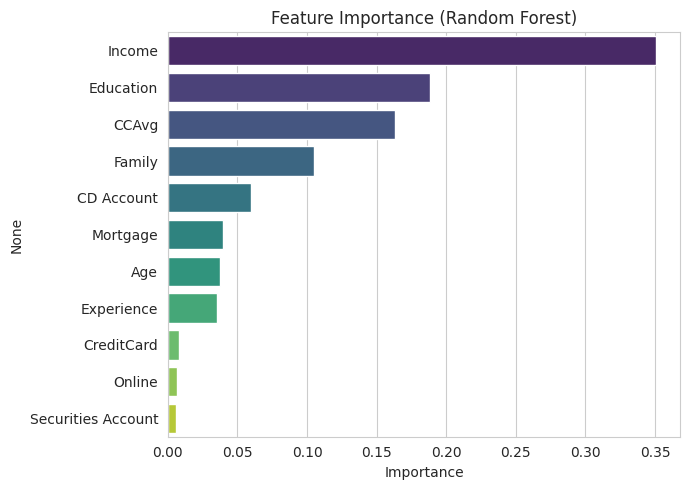

,0
Income,0.350474
Education,0.188512
CCAvg,0.163300
Family,0.105304
CD Account,0.059884
Mortgage,0.039682
Age,0.037679
Experience,0.035608
CreditCard,0.007686
Online,0.006376


In [21]:
rf_model = models["Random Forest"][1]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("07_feature_importance.png", dpi=150)
plt.show()

importances

## Step 11 — Download everything (plots, leaderboard) to your computer


In [23]:
import os, zipfile

out_files = [f for f in os.listdir(".") if f.endswith((".png", ".csv"))]
print("Zipping:", out_files)

with zipfile.ZipFile("project_outputs.zip", "w") as zf:
    for f in out_files:
        zf.write(f)

print("Zip created:", os.path.getsize("project_outputs.zip"), "bytes")

from google.colab import files as colab_files
colab_files.download("project_outputs.zip")

Zipping: ['cm_Decision_Tree.png', 'cm_Logistic_Regression.png', 'leaderboard.csv', '02_correlation_heatmap.png', '05_leaderboard_chart.png', '01_target_distribution.png', 'cm_KNN.png', 'Bank_Personal_Loan_Modelling.csv', '03_income_vs_loan.png', '06_roc_curves.png', 'cm_Random_Forest.png', '07_feature_importance.png', '04_education_vs_loan.png']
Zip created: 786550 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>